In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#pilgrim_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/pilgrimBdata.csv")
pilgrim_data = pd.read_csv("pilgrimBdata.csv")

In [ ]:
pilgrim_data
# CK: Seems like we have missing data problem. We don't need to do anything about it till Q3

,ID,Profit99,Online99,Age99,Inc99,Tenure99,District99,Profit00,Online00,Billpay99,Billpay00
0,1,21,0,NaN,NaN,6.33,1200,NaN,NaN,0,NaN
1,2,-6,0,6.0,3.0,29.50,1200,-32.0,0.0,0,0.0
2,3,-49,1,5.0,5.0,26.41,1100,-22.0,1.0,0,0.0
3,4,-4,0,NaN,NaN,2.25,1200,NaN,NaN,0,NaN
4,5,-61,0,2.0,9.0,9.91,1200,-4.0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
31629,31630,-50,0,5.0,5.0,3.75,1200,1.0,0.0,0,0.0
31630,31631,458,0,3.0,8.0,12.08,1300,423.0,1.0,0,0.0
31631,31632,-83,0,6.0,4.0,15.83,1200,-60.0,0.0,0,0.0
31632,31633,92,1,1.0,6.0,5.41,1200,170.0,1.0,0,0.0


In [ ]:
# CK: Let's check the percentage of missing values for each columns

# Calculating percentage of NaN values for each column
missing_percentage = pilgrim_data.isnull().mean() * 100

print(missing_percentage)

ID             0.000000
Profit99       0.000000
Online99       0.000000
Age99         26.202820
Inc99         26.114307
Tenure99       0.000000
District99     0.000000
Profit00      16.558134
Online00      16.498072
Billpay99      0.000000
Billpay00     16.498072
dtype: float64


CK: NaN being 16~26%, deleting is not on option., first perhaps we can think of doing imputation by using mean values.
--> No need to do right now, this is taken care of in Q3.

## Question 1. Re-create the “profitability skew” discussed in the case (see Exhibit 3).

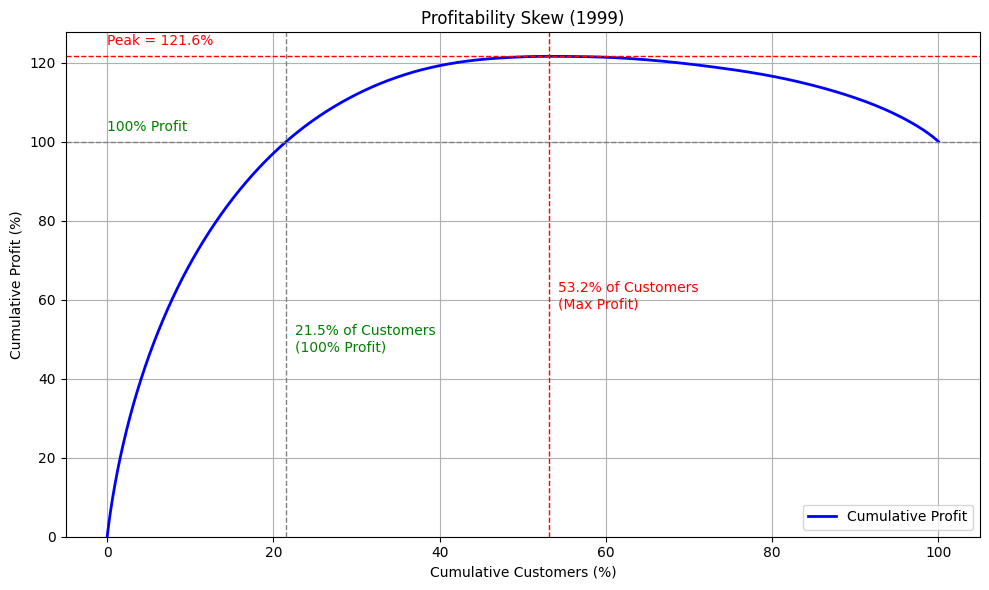

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_sorted = pilgrim_data.sort_values(by="Profit99", ascending=False).reset_index(drop=True)

total_profit = df_sorted["Profit99"].sum()
df_sorted["CumProfitPct"] = df_sorted["Profit99"].cumsum() / total_profit * 100

n_customers = len(df_sorted)
df_sorted["CumCustPct"] = (df_sorted.index + 1) / n_customers * 100

# Finding % of customers that give us 100% profit
idx_100 = df_sorted[df_sorted["CumProfitPct"] >= 100].index.min()
custFrac_100 = df_sorted.loc[idx_100, "CumCustPct"]

# Finding  % customers that gives the maximum profit
idx_peak = df_sorted["CumProfitPct"].idxmax()
peakProfit = df_sorted.loc[idx_peak, "CumProfitPct"]
custFrac_peak = df_sorted.loc[idx_peak, "CumCustPct"]

# Plotting the “whale” curve
plt.figure(figsize=(10, 6))
plt.plot(df_sorted["CumCustPct"], df_sorted["CumProfitPct"],
         color="blue", linewidth=2, label="Cumulative Profit")

plt.axhline(y=100, color="gray", linestyle="--", linewidth=1)
plt.axvline(x=custFrac_100, color="gray", linestyle="--", linewidth=1)
plt.axhline(y=peakProfit, color="red", linestyle="--", linewidth=1)
plt.axvline(x=custFrac_peak, color="red", linestyle="--", linewidth=1)

plt.text(0, 102, "100% Profit", color="green", ha="left", va="bottom")
plt.text(custFrac_100 + 1, 50, f"{custFrac_100:.1f}% of Customers\n(100% Profit)",
         color="green", ha="left", va="center")

plt.text(0, peakProfit + 2, f"Peak = {peakProfit:.1f}%", color="red", ha="left", va="bottom")
plt.text(custFrac_peak + 1, peakProfit/2,
         f"{custFrac_peak:.1f}% of Customers\n(Max Profit)",
         color="red", ha="left", va="center")

plt.title("Profitability Skew (1999)")
plt.xlabel("Cumulative Customers (%)")
plt.ylabel("Cumulative Profit (%)")
plt.grid(True)
plt.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

## Question 2. Evaluate the heterogeneity in customer profitability:  

a.
Currently Pilgrim Bank has 31,634 customers that generate 100% of profit. They could realize the same profit with less customers. Determine the minimum percentage of customers that Pilgrim Bank would need to realize 100% of their current profit.  

**ANSWER: 21.53%**

b.
Determine the percentage of total profit Pilgrim Bank could realize by targeting profitable customers only. What is the percentage of customers they need to realize this maximum profit?

**ANSWER: 121.58%, 53.21%**

In [ ]:

pilgrim_data_sorted = pilgrim_data.sort_values(by="Profit99", ascending=False)

total_profit = pilgrim_data_sorted["Profit99"].sum()
pilgrim_data_sorted["Cumulative_Profit"] = pilgrim_data_sorted["Profit99"].cumsum()

needed_customers = (pilgrim_data_sorted["Cumulative_Profit"] <= total_profit).sum()

total_customers = len(pilgrim_data_sorted)
min_percentage_customers = (needed_customers / total_customers) * 100

print(f"Minimum percentage of customers needed to achieve 100% of profit: {min_percentage_customers:.2f}%")

Minimum percentage of customers needed to achieve 100% of profit: 21.53%


In [ ]:
import pandas as pd

total_profit_all = pilgrim_data["Profit99"].sum()

profitable_customers = pilgrim_data[pilgrim_data["Profit99"] > 0]

total_profit_profitable = profitable_customers["Profit99"].sum()

profit_percentage = (total_profit_profitable / total_profit_all) * 100

percentage_profitable_customers = (len(profitable_customers) / len(pilgrim_data)) * 100

print(f"Maximum cumulative profit from profitable customers: {total_profit_profitable:.2f}")
print(f"Percentage of total profit achieved by profitable customers: {profit_percentage:.2f}%")
print(f"Percentage of customers needed to achieve this profit: {percentage_profitable_customers:.2f}%")

Maximum cumulative profit from profitable customers: 4288303.00
Percentage of total profit achieved by profitable customers: 121.58%
Percentage of customers needed to achieve this profit: 53.21%


## Question 3. What role do demographic variables play here? Follow the instructions in a and b when it comes to demographic variables. How does including demographics affect your conclusion on the profitability difference between customers who used online banking and those not?  

a.
According to Exhibit 4, the variables age and income are categorized as categorical. Using the mappings provided below, create new variables for age and income by replacing the categorical values with their corresponding numeric values:  
i.
Age Mapping:   
{1: 10, 2: 20, 3: 30, 4: 40, 5: 50, 6: 60, 7: 70}.   
ii.
Income Mapping:  
{1: 12,500, 2: 17,500, 3: 25,000, 4: 35,000, 5: 45,000, 6: 62,500, 7: 87,500, 8: 112,500, 9: 150,000}.

b.
create a dummy “AgeMiss” to indicate missing data on Age, and create another variable “AgeMean” with mean replacement on NA. Similarly, create ‘IncMiss’ and ‘IncMean’.

In [ ]:

age_mapping = {1: 10, 2: 20, 3: 30, 4: 40, 5: 50, 6: 60, 7: 70}
income_mapping = {1: 12500, 2: 17500, 3: 25000, 4: 35000,
                  5: 45000, 6: 62500, 7: 87500, 8: 112500, 9: 150000}

pilgrim_data["Age99"] = pilgrim_data["Age99"].replace(age_mapping)
pilgrim_data["Inc99"] = pilgrim_data["Inc99"].replace(income_mapping)

print(pilgrim_data[["Age99", "Inc99"]].head())

   Age99     Inc99
0    NaN       NaN
1   60.0   25000.0
2   50.0   45000.0
3    NaN       NaN
4   20.0  150000.0


In [ ]:
pilgrim_data["AgeMiss"] = pilgrim_data["Age99"].isnull().astype(int)
pilgrim_data["IncMiss"] = pilgrim_data["Inc99"].isnull().astype(int)

age_mean = pilgrim_data["Age99"].mean()
income_mean = pilgrim_data["Inc99"].mean()

pilgrim_data["AgeMean"] = pilgrim_data["Age99"].fillna(age_mean)
pilgrim_data["IncMean"] = pilgrim_data["Inc99"].fillna(income_mean)

print(pilgrim_data[["Age99", "AgeMiss", "AgeMean", "Inc99", "IncMiss", "IncMean"]].head())

   Age99  AgeMiss    AgeMean     Inc99  IncMiss        IncMean
0    NaN        1  40.460484       NaN        1   66128.117914
1   60.0        0  60.000000   25000.0        0   25000.000000
2   50.0        0  50.000000   45000.0        0   45000.000000
3    NaN        1  40.460484       NaN        1   66128.117914
4   20.0        0  20.000000  150000.0        0  150000.000000


In [ ]:
# CK: now let's check.
missing_percentage = pilgrim_data.isnull().mean() * 100

print(missing_percentage)

ID             0.000000
Profit99       0.000000
Online99       0.000000
Age99         26.202820
Inc99         26.114307
Tenure99       0.000000
District99     0.000000
Profit00      16.558134
Online00      16.498072
Billpay99      0.000000
Billpay00     16.498072
AgeMiss        0.000000
IncMiss        0.000000
AgeMean        0.000000
IncMean        0.000000
dtype: float64


In [ ]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Model 1: Profit99 ~ Online99
model1 = smf.ols(formula="Profit99 ~ Online99", data=pilgrim_data).fit()
print("\nModel 1 Results:\n", model1.summary())

# Model 2: Profit99 ~ Online99 + AgeMiss + AgeMean + Tenure99 + C(District99)
model2 = smf.ols(formula="Profit99 ~ Online99 + AgeMiss + AgeMean + Tenure99 + C(District99)", data=pilgrim_data).fit()
print("\nModel 2 Results:\n", model2.summary())

# Model 3: Profit99 ~ Online99 + IncMiss + IncMean + Tenure99 + C(District99)
model3 = smf.ols(formula="Profit99 ~ Online99 + IncMiss + IncMean + Tenure99 + C(District99)", data=pilgrim_data).fit()
print("\nModel 3 Results:\n", model3.summary())

# Model 4: Profit99 ~ Online99 + AgeMiss + AgeMean + IncMiss + IncMean + Tenure99 + C(District99)
model4 = smf.ols(formula="Profit99 ~ Online99 + AgeMiss + AgeMean + IncMiss + IncMean + Tenure99 + C(District99)", data=pilgrim_data).fit()
print("\nModel 4 Results:\n", model4.summary())


Model 1 Results:
                             OLS Regression Results                            
Dep. Variable:               Profit99   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.572
Date:                Mon, 10 Mar 2025   Prob (F-statistic):              0.210
Time:                        01:14:27   Log-Likelihood:            -2.2232e+05
No. Observations:               31634   AIC:                         4.446e+05
Df Residuals:                   31632   BIC:                         4.447e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    110.7862      1.637 

### **Interpretation of Regression Models**

As we analyzed four variations of the model, it is evident that **demographic information (age and income) impacts profitability**, making online banking customers more profitable when these factors are considered.

- **Model 1 (Only Online99 included)**:  
  - There was **no significant effect** of online banking on profitability.  
  - The **Online99 coefficient** had a **p-value of 0.210**, meaning it was **not statistically significant**.

- **Model 2 (Adding Age Variables)**:  
  - When **age-related variables** were added, **online banking became more significant**, showing that **older age and longer tenure lead to higher profitability**.

- **Model 3 (Adding Income Variables)**:  
  - When **income variables** were included, **online banking became insignificant**, with a **p-value of 0.274**.  
  - This suggests that **income, rather than online banking itself, explains the differences in profitability**.

- **Model 4 (Adding Both Age & Income Variables)**:  
  - When **both age and income variables** were added, **online banking became statistically significant again**.  
  - This means that **when demographic factors are considered, online banking users are indeed more profitable**.

---

### **Key Model 4 Coefficients & Interpretation**
1. **Online99 Coefficient: 13.22**  
   - Online banking customers **earn $13.22 more** in profit.  
   - This effect is **statistically significant** (**p = 0.004**).

2. **AgeMiss Coefficient: -5.14**  
   - If a customer’s **age is missing**, they are **$5.14 less profitable** on average.

3. **AgeMean Coefficient: 1.66**  
   - **Each additional year of age** results in **$1.66 more profit**.

4. **IncMiss Coefficient: -34.27**  
   - If a customer’s **income data is missing**, they are **$34.27 less profitable**.

5. **IncMean Coefficient: 0.001**  
   - **Each $1 increase in income** results in a **$0.001 increase in profit**.  
   - For example, a **$10,000 increase in income** leads to a **$10 increase in profit**.

6. **Tenure99 Coefficient: 4.73**  
   - If a customer has been with the bank **one additional year**, this leads to an **additional $4.73 in profit**.

7. **District1200 Coefficient: 19.59**  
   - Customers **living in District1200** generate **$19.59 more profit** than the reference district.

8. **District1300 Coefficient: 8.28**  
   - Customers **living in District1300** generate **$8.28 more profit** than the reference district.

---

### **Final Summary**
- **Online banking is significantly associated with higher profitability** when controlling for demographic factors.  
- **Age, tenure, and income play an important role in determining profitability**.  
- **Missing data (age and income) is associated with lower profitability**, suggesting a need for further investigation.  
- **Regional differences persist**, indicating that profitability varies by district.  

## Question 5. How well does customer channel use in 1999 predict how profitable customers will be in 2000 after controlling for all the other variables?


In [ ]:
import statsmodels.formula.api as smf

formula = "Profit00 ~ Online99 + AgeMiss + AgeMean + IncMiss + IncMean + Tenure99 + C(District99)"

model = smf.ols(formula, data=pilgrim_data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Profit00   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     126.7
Date:                Mon, 10 Mar 2025   Prob (F-statistic):          1.72e-209
Time:                        01:14:27   Log-Likelihood:            -1.9444e+05
No. Observations:               26396   AIC:                         3.889e+05
Df Residuals:                   26387   BIC:                         3.890e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -65.13

## Question 6. How well does customer channel use in 1999 predict whether customers stay with the bank through 2000 after controlling for all the other variables?

In [ ]:
import pandas as pd
import numpy as np

pilgrim_data["Stay00"] = np.where(
    pilgrim_data["Profit00"].notna(), 1, 0
)

In [ ]:
import statsmodels.formula.api as smf

df_retain = pilgrim_data.copy()

formula = (
    "Stay00 ~ Online99 "
    "+ AgeMiss + AgeMean "
    "+ IncMiss + IncMean "
    "+ Tenure99 "
    "+ C(District99)"
)

model_logit = smf.logit(formula, data=df_retain).fit()

print(model_logit.summary())


Optimization terminated successfully.
         Current function value: 0.368420
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Stay00   No. Observations:                31634
Model:                          Logit   Df Residuals:                    31625
Method:                           MLE   Df Model:                            8
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:                  0.1791
Time:                        01:14:28   Log-Likelihood:                -11655.
converged:                       True   LL-Null:                       -14198.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.5807      0.088     17.970      0.000       1.408       1.

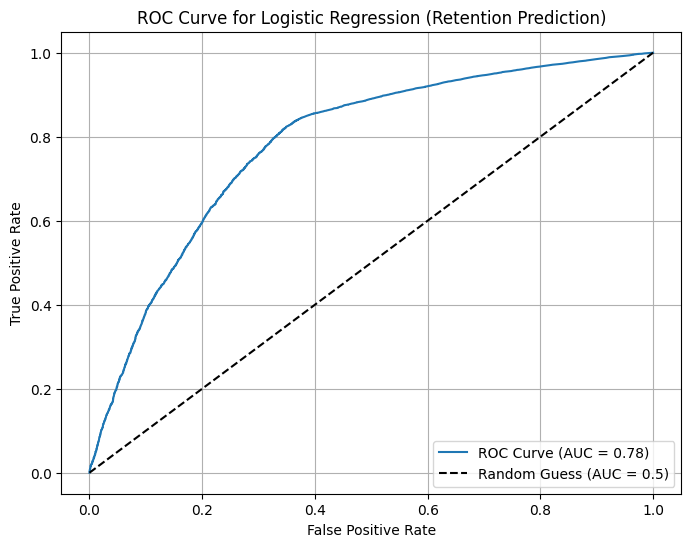

AUC Score: 0.7835


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_true = df_retain['Stay00']
y_scores = model_logit.predict(df_retain)
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

auc_score = roc_auc_score(y_true, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression (Retention Prediction)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score: {auc_score:.4f}")